<a href="https://colab.research.google.com/github/fatmaahmed33/portfolio/blob/main/bedtime_sleep_cleaning_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bedtime Screen Time & Sleep Debt  
## Pandas Cleaning, Exploration, and Feature Engineering — Full Solution

**Dataset:** `bedtime_screentime_sleep_debt(1).csv`

This notebook completes all 15 tasks using **pandas**.  
The workflow covers data inspection, quality checks, outlier detection, exploratory analysis, and feature engineering.


## TODO 1: Load and preview the dataset

**Task:** Load the CSV into a DataFrame, then inspect the first few rows.

**Hint: use `pd.read_csv()` and `.head()`.**


In [ ]:
# TODO 1: Load and preview the dataset
import pandas as pd
import numpy as np

DATA_PATH = "bedtime_screentime_sleep_debt.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
display(df.head())

Dataset loaded successfully.


,user_id,age,gender,occupation_type,chronotype,bedtime_phone_minutes,primary_bedtime_app,screen_brightness_pct,blue_light_filter_active,caffeine_post_5pm_mg,physical_activity_min,sleep_latency_min,total_sleep_hours,deep_sleep_pct,rem_sleep_pct,morning_alarm_snoozes,next_day_fatigue_score,sleep_debt_category
0,USR-00001,29,Female,Healthcare / Shift Worker,Intermediate,179,Instagram / Reddit,54,1,0,21,84.4,3.20,23.5,22.2,7,10.0,Severe Sleep Debt
1,USR-00002,58,Female,Student,Intermediate,163,YouTube,76,1,92,72,86.7,4.06,18.0,21.5,7,10.0,Severe Sleep Debt
2,USR-00003,41,Female,Healthcare / Shift Worker,Night Owl,100,TikTok / Reels,59,0,45,23,70.5,3.20,18.1,20.5,7,10.0,Severe Sleep Debt
3,USR-00004,36,Non-Binary,Remote Tech,Intermediate,34,YouTube,52,0,97,49,38.1,6.99,21.6,22.4,1,1.7,Mild Deficit
4,USR-00005,23,Female,Healthcare / Shift Worker,Intermediate,27,TikTok / Reels,82,1,0,38,32.3,4.58,24.1,22.8,4,5.3,Moderate Debt


## TODO 2: Understand the dataset structure

**Task:** Find the number of rows and columns, column names, and data types.

**Hint: use `.shape`, `.columns`, and `.info()`.**


In [ ]:
# TODO 2: Understand the dataset structure
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataFrame information:")
df.info()


Number of rows: 8500
Number of columns: 18

Column names:
['user_id', 'age', 'gender', 'occupation_type', 'chronotype', 'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct', 'blue_light_filter_active', 'caffeine_post_5pm_mg', 'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes', 'next_day_fatigue_score', 'sleep_debt_category']

DataFrame information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   8500 non-null   object 
 1   age                       8500 non-null   int64  
 2   gender                    8500 non-null   object 
 3   occupation_type           8500 non-null   object 
 4   chronotype                8500 non-null   object 
 5   bedtime_phone_minutes     8500 non-null   int64  
 6   pri

## TODO 3: Generate basic descriptive statistics

**Task:** Summarize numerical columns and inspect categorical columns.

**Hint: use `.describe()` and `.value_counts()` for selected categorical columns.**


In [ ]:
# TODO 3: Generate basic descriptive statistics
print("Numerical columns:")
display(df.describe().T)

categorical_cols = [
    "gender",
    "occupation_type",
    "chronotype",
    "primary_bedtime_app",
    "sleep_debt_category",
]

print("\nCategorical value counts:")
for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False))


Numerical columns:


,count,mean,std,min,25%,50%,75%,max
age,8500.0,34.355647,11.584259,18.0,25.00,32.00,42.00,65.0
bedtime_phone_minutes,8500.0,59.250000,36.931991,1.0,31.00,51.00,79.00,180.0
screen_brightness_pct,8500.0,55.153882,19.850550,10.0,42.00,55.00,69.00,100.0
blue_light_filter_active,8500.0,0.467765,0.498989,0.0,0.00,0.00,1.00,1.0
caffeine_post_5pm_mg,8500.0,33.222471,51.935645,0.0,0.00,0.00,55.00,250.0
physical_activity_min,8500.0,35.701412,20.819390,0.0,21.00,35.00,50.00,112.0
sleep_latency_min,8500.0,40.671471,17.444914,6.0,28.20,37.60,49.70,123.3
total_sleep_hours,8500.0,6.266209,1.446258,3.2,5.24,6.33,7.35,9.8
deep_sleep_pct,8500.0,21.735741,3.069377,8.1,19.70,21.90,23.90,28.0
rem_sleep_pct,8500.0,19.105859,2.546459,9.6,17.40,19.10,20.80,27.0



Categorical value counts:

--- gender ---


,count
gender,
Female,4347
Male,3905
Non-Binary,248



--- occupation_type ---


...

,count
chronotype,
Intermediate,3880
Night Owl,2455
Morning Lark,2165



--- primary_bedtime_app ---


,count
primary_bedtime_app,
TikTok / Reels,2198
YouTube,1928
Instagram / Reddit,1630
Streaming (Netflix/Hulu),1301
Messaging / Chat,847
News / Reading,596



--- sleep_debt_category ---


,count
sleep_debt_category,
Moderate Debt,4462
Mild Deficit,2004
Optimal Recovery,1387
Severe Sleep Debt,647


## TODO 4: Check missing values

**Task:** Find whether any columns contain missing values and calculate how many.

**Hint: combine `.isna()` with `.sum()`.**


In [ ]:
# TODO 4: Check missing values
missing_count = df.isna().sum()
missing_pct = (df.isna().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_pct
})

display(missing_report)

print("Total missing values in the dataset:", int(missing_count.sum()))


,missing_count,missing_percent
user_id,0,0.0
age,0,0.0
gender,0,0.0
occupation_type,0,0.0
chronotype,0,0.0
bedtime_phone_minutes,0,0.0
primary_bedtime_app,0,0.0
screen_brightness_pct,0,0.0
blue_light_filter_active,0,0.0
caffeine_post_5pm_mg,0,0.0


Total missing values in the dataset: 0


## TODO 5: Check duplicates

**Task:** Check for fully duplicated rows and duplicated user IDs.

**Hint: use `.duplicated()` and filter/select `user_id` when needed.**


In [ ]:
# TODO 5: Check duplicates
full_duplicates = df.duplicated().sum()
user_id_duplicates = df["user_id"].duplicated().sum()

print("Fully duplicated rows:", full_duplicates)
print("Duplicated user IDs:", user_id_duplicates)

if user_id_duplicates > 0:
    print("\nRows with duplicated user IDs:")
    display(df[df["user_id"].duplicated(keep=False)].sort_values("user_id"))


Fully duplicated rows: 0
Duplicated user IDs: 0


## TODO 6: Inspect categorical values

**Task:** Check the unique values in the main categorical columns and look for inconsistent labels or spelling.

**Hint: use `.unique()`, `.nunique()`, and `.value_counts()`.**


In [ ]:
# TODO 6: Inspect categorical values
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n===== {col} =====")
    print("Number of unique values:", df[col].nunique(dropna=False))

    # user_id has one value per person, so showing all 8,500 IDs is not useful.
    if col == "user_id":
        display(df[col].head(10))
    else:
        display(df[col].value_counts(dropna=False))

# Basic text cleaning: remove accidental leading/trailing spaces.
# This does not change correctly formatted labels.
for col in categorical_cols:
    df[col] = df[col].str.strip()



===== user_id =====
Number of unique values: 8500


,user_id
0,USR-00001
1,USR-00002
2,USR-00003
3,USR-00004
4,USR-00005
5,USR-00006
6,USR-00007
7,USR-00008
8,USR-00009
9,USR-00010



===== gender =====
Number of unique values: 3


,count
gender,
Female,4347
Male,3905
Non-Binary,248



===== occupation_type =====
Number of unique values: 5


...

,count
chronotype,
Intermediate,3880
Night Owl,2455
Morning Lark,2165



===== primary_bedtime_app =====
Number of unique values: 6


,count
primary_bedtime_app,
TikTok / Reels,2198
YouTube,1928
Instagram / Reddit,1630
Streaming (Netflix/Hulu),1301
Messaging / Chat,847
News / Reading,596



===== sleep_debt_category =====
Number of unique values: 4


,count
sleep_debt_category,
Moderate Debt,4462
Mild Deficit,2004
Optimal Recovery,1387
Severe Sleep Debt,647


## TODO 7: Validate numerical ranges

**Task:** Inspect minimum and maximum values and identify impossible or suspicious values.

**Hint: use `.min()`, `.max()`, `.describe()`, and Boolean filtering.**


In [ ]:
# TODO 7: Validate numerical ranges
numeric_cols = df.select_dtypes(include=np.number).columns

range_summary = pd.DataFrame({
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
}).round(2)

display(range_summary)

,min,max,mean,median
age,18.0,65.0,34.36,32.00
bedtime_phone_minutes,1.0,180.0,59.25,51.00
screen_brightness_pct,10.0,100.0,55.15,55.00
blue_light_filter_active,0.0,1.0,0.47,0.00
caffeine_post_5pm_mg,0.0,250.0,33.22,0.00
physical_activity_min,0.0,112.0,35.70,35.00
sleep_latency_min,6.0,123.3,40.67,37.60
total_sleep_hours,3.2,9.8,6.27,6.33
deep_sleep_pct,8.1,28.0,21.74,21.90
rem_sleep_pct,9.6,27.0,19.11,19.10


## TODO 8: Detect possible outliers

**Task:** Choose 2–3 numerical columns, such as sleep latency, bedtime phone minutes, or physical activity, and identify possible outliers.

**Hint: calculate Q1, Q3, and IQR with `.quantile()` and use Boolean conditions.**


df[[True, False, True]]

In [ ]:
# TODO 8: Detect possible outliers
outlier_cols = [
    "sleep_latency_min",
    "bedtime_phone_minutes",
    "physical_activity_min",
]

outlier_rows = []
outlier_summary = []

for col in outlier_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    mask = (df[col] < lower_bound) | (df[col] > upper_bound)

    outlier_summary.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(mask.sum()),
        "outlier_percent": round(mask.mean() * 100, 2),
    })

    temp = df.loc[mask, ["user_id", col]].copy()
    temp["outlier_column"] = col
    temp["lower_bound"] = lower_bound
    temp["upper_bound"] = upper_bound
    outlier_rows.append(temp)

outlier_summary = pd.DataFrame(outlier_summary).round(2)
display(outlier_summary)

all_outliers = pd.concat(outlier_rows, ignore_index=True)
print("Example detected outliers:")
display(all_outliers.head(15))

print(
    "\nImportant: IQR outliers are unusual observations, not automatically errors, "
    "so they are kept unless there is evidence that they are invalid."
)


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,sleep_latency_min,28.2,49.7,21.5,-4.05,81.95,247,2.91
1,bedtime_phone_minutes,31.0,79.0,48.0,-41.00,151.00,237,2.79
2,physical_activity_min,21.0,50.0,29.0,-22.50,93.50,40,0.47


Example detected outliers:


,user_id,sleep_latency_min,outlier_column,lower_bound,upper_bound,bedtime_phone_minutes,physical_activity_min
0,USR-00001,84.4,sleep_latency_min,-4.05,81.95,NaN,NaN
1,USR-00002,86.7,sleep_latency_min,-4.05,81.95,NaN,NaN
2,USR-00054,84.7,sleep_latency_min,-4.05,81.95,NaN,NaN
3,USR-00072,102.2,sleep_latency_min,-4.05,81.95,NaN,NaN
4,USR-00116,82.4,sleep_latency_min,-4.05,81.95,NaN,NaN
5,USR-00159,82.7,sleep_latency_min,-4.05,81.95,NaN,NaN
6,USR-00234,106.8,sleep_latency_min,-4.05,81.95,NaN,NaN
7,USR-00333,104.5,sleep_latency_min,-4.05,81.95,NaN,NaN
8,USR-00346,92.9,sleep_latency_min,-4.05,81.95,NaN,NaN
9,USR-00403,95.4,sleep_latency_min,-4.05,81.95,NaN,NaN



Important: IQR outliers are unusual observations, not automatically errors, so they are kept unless there is evidence that they are invalid.


## TODO 9: Explore one numerical variable

**Task:** Study the distribution of one important variable, such as total sleep hours.

**Hint: inspect mean, median, standard deviation, and grouped ranges using `.mean()`, `.median()`, `.std()`, or `pd.cut()`.**


In [ ]:
# TODO 9: Explore one numerical variable
sleep_stats = df["total_sleep_hours"].agg(["count", "mean", "median", "std", "min", "max"])
print("Total sleep hours summary:")
display(sleep_stats.to_frame("value").round(2))

sleep_bins = [0, 5, 6, 7, 8, np.inf]
sleep_labels = ["<5 h", "5–<6 h", "6–<7 h", "7–<8 h", "8+ h"]

df["sleep_duration_group"] = pd.cut(
    df["total_sleep_hours"],
    bins=sleep_bins,
    labels=sleep_labels,
    right=False,
    include_lowest=True,
)

print("\nSleep-duration groups:")
sleep_group_counts = (
    df["sleep_duration_group"]
    .value_counts(sort=False)
    .rename("count")
    .to_frame()
)
sleep_group_counts["percent"] = (
    sleep_group_counts["count"] / len(df) * 100
).round(2)

display(sleep_group_counts)


Total sleep hours summary:


,value
count,8500.00
mean,6.27
median,6.33
std,1.45
min,3.20
max,9.80



Sleep-duration groups:


,count,percent
sleep_duration_group,,
<5 h,1713,20.15
5–<6 h,1820,21.41
6–<7 h,2097,24.67
7–<8 h,1887,22.20
8+ h,983,11.56


## TODO 10: Explore categorical vs. numerical relationships

**Task:** Compare average sleep duration or fatigue across one categorical variable such as chronotype or occupation type.

**Hint: use `.groupby()` with `.mean()` or `.agg()`.**


In [ ]:
# TODO 10: Explore categorical vs. numerical relationships
chronotype_summary = (
    df.groupby("chronotype")
      .agg(
          people=("user_id", "size"),
          avg_sleep_hours=("total_sleep_hours", "mean"),
          avg_sleep_latency=("sleep_latency_min", "mean"),
          avg_fatigue=("next_day_fatigue_score", "mean"),
          avg_bedtime_phone_minutes=("bedtime_phone_minutes", "mean"),
      )
      .round(2)
      .sort_values("avg_sleep_hours", ascending=False)
)

display(chronotype_summary)
# select chronotype, mean(total_sleep_hours). mean(sleep_latency_min), mean(next_day_fatigue_score) from df group by chronotype

,people,avg_sleep_hours,avg_sleep_latency,avg_fatigue,avg_bedtime_phone_minutes
chronotype,,,,,
Morning Lark,2165,7.38,40.90,2.53,59.75
Intermediate,3880,6.44,40.83,3.48,59.57
Night Owl,2455,5.01,40.22,5.40,58.31


## TODO 11: Explore phone use and sleep

**Task:** Investigate whether bedtime phone usage is related to sleep duration, sleep latency, or fatigue.

**Hint: use `.corr()` for numerical relationships or create phone-use groups with `pd.cut()` / `pd.qcut()` and then `.groupby()`.**


In [ ]:
# TODO 11: Explore phone use and sleep
relationship_cols = [
    "bedtime_phone_minutes",
    "total_sleep_hours",
    "sleep_latency_min",
    "next_day_fatigue_score",
]

print("Correlation matrix:")
phone_sleep_corr = df[relationship_cols].corr().round(3)
display(phone_sleep_corr)

# Divide bedtime phone use into four equally sized groups.
df["phone_use_quartile"] = pd.qcut(
    df["bedtime_phone_minutes"],
    q=4,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4 Highest"],
)

phone_quartile_summary = (
    df.groupby("phone_use_quartile", observed=False)
      .agg(
          people=("user_id", "size"),
          avg_phone_minutes=("bedtime_phone_minutes", "mean"),
          avg_sleep_hours=("total_sleep_hours", "mean"),
          avg_sleep_latency=("sleep_latency_min", "mean"),
          avg_fatigue=("next_day_fatigue_score", "mean"),
      )
      .round(2)
)

print("\nSleep measures across bedtime phone-use quartiles:")
display(phone_quartile_summary)

print(
    "\nNote: correlation describes association in this dataset; "
    "it does not by itself prove causation."
)


Correlation matrix:


,bedtime_phone_minutes,total_sleep_hours,sleep_latency_min,next_day_fatigue_score
bedtime_phone_minutes,1.000,-0.554,0.858,0.711
total_sleep_hours,-0.554,1.000,-0.527,-0.879
sleep_latency_min,0.858,-0.527,1.000,0.745
next_day_fatigue_score,0.711,-0.879,0.745,1.000



Sleep measures across bedtime phone-use quartiles:


,people,avg_phone_minutes,avg_sleep_hours,avg_sleep_latency,avg_fatigue
phone_use_quartile,,,,,
Q1 Lowest,2163,20.65,7.14,25.31,1.94
Q2,2097,41.52,6.65,33.30,2.70
Q3,2122,64.15,6.13,42.46,3.96
Q4 Highest,2118,111.32,5.13,61.86,6.60



Note: correlation describes association in this dataset; it does not by itself prove causation.


## TODO 12: Create a total sleep-quality feature

**Task:** Create one new feature that summarizes sleep quality using available sleep-related variables.

**Hint: combine columns such as total sleep hours, sleep latency, deep sleep percentage, REM percentage, or fatigue. Decide and document your own rule.**


In [ ]:
# TODO 12: Create a total sleep-quality feature
# Educational heuristic only, not a clinical sleep score.
# One point is awarded for each condition below:
#   1) 7–9 hours of sleep
#   2) sleep latency <= 30 minutes
#   3) deep sleep >= 20%
#   4) REM sleep >= 20%
#   5) next-day fatigue <= 3
# Final score ranges from 0 to 5.

df["sleep_quality_score"] = (
    df["total_sleep_hours"].between(7, 9).astype(int)
    + (df["sleep_latency_min"] <= 30).astype(int)
    + (df["deep_sleep_pct"] >= 20).astype(int)
    + (df["rem_sleep_pct"] >= 20).astype(int)
    + (df["next_day_fatigue_score"] <= 3).astype(int)
)

print("Sleep-quality score distribution:")
display(
    df["sleep_quality_score"]
      .value_counts()
      .sort_index()
      .rename_axis("sleep_quality_score")
      .to_frame("count")
)

print("Average sleep-quality score:", round(df["sleep_quality_score"].mean(), 2))


Sleep-quality score distribution:


,count
sleep_quality_score,
0,1038
1,2099
2,1850
3,1645
4,1384
5,484


Average sleep-quality score: 2.2


## TODO 13: Create a bedtime phone-use category

**Task:** Convert bedtime phone minutes into meaningful categories such as low, moderate, and high usage.

**Hint: use `pd.cut()` or `pd.qcut()` and store the result in a new column.**


In [ ]:
# TODO 13: Create a bedtime phone-use category
df["phone_use_category"] = pd.cut(
    df["bedtime_phone_minutes"],
    bins=[0, 30, 60, np.inf],
    labels=["Low", "Moderate", "High"],
    include_lowest=True,
)

print("Phone-use category distribution:")
display(
    df["phone_use_category"]
      .value_counts(sort=False)
      .rename("count")
      .to_frame()
)

print("\nAverage sleep measures by phone-use category:")
display(
    df.groupby("phone_use_category", observed=False)
      .agg(
          people=("user_id", "size"),
          avg_sleep_hours=("total_sleep_hours", "mean"),
          avg_sleep_latency=("sleep_latency_min", "mean"),
          avg_fatigue=("next_day_fatigue_score", "mean"),
      )
      .round(2)
)


Phone-use category distribution:


,count
phone_use_category,
Low,2051
Moderate,3038
High,3411



Average sleep measures by phone-use category:


,people,avg_sleep_hours,avg_sleep_latency,avg_fatigue
phone_use_category,,,,
Low,2051,7.15,25.04,1.93
Moderate,3038,6.58,34.79,2.88
High,3411,5.45,55.31,5.73


## TODO 14: Create one interaction feature

**Task:** Create a feature that combines two related variables, for example screen brightness with phone duration, or caffeine with bedtime phone use.

**Hint: create a new column using arithmetic between existing columns.**


In [ ]:
# TODO 14: Create one interaction feature
# A simple screen-exposure index combining duration and brightness.
# Example: 60 minutes at 50% brightness -> 30 exposure units.
df["bedtime_screen_exposure"] = (
    df["bedtime_phone_minutes"] * df["screen_brightness_pct"] / 100
)

print("Bedtime screen exposure summary:")
display(df["bedtime_screen_exposure"].describe().round(2))

print("\nExample rows:")
display(
    df[
        [
            "bedtime_phone_minutes",
            "screen_brightness_pct",
            "bedtime_screen_exposure",
        ]
    ].head()
)


Bedtime screen exposure summary:


,bedtime_screen_exposure
count,8500.00
mean,32.68
std,24.54
min,0.57
25%,14.85
50%,26.55
75%,44.00
max,180.00



Example rows:


,bedtime_phone_minutes,screen_brightness_pct,bedtime_screen_exposure
0,179,54,96.66
1,163,76,123.88
2,100,59,59.00
3,34,52,17.68
4,27,82,22.14


## TODO 15: Final review

**Task:** Display the cleaned dataset, confirm its shape, review the new features, and summarize what you discovered in 3–5 short observations.

**Hint: use `.head()`, `.shape`, `.columns`, `.describe()`, and your earlier grouped results.**


In [ ]:
# TODO 15: Final review
print("Final dataset shape:", df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

new_features = [
    "sleep_duration_group",
    "phone_use_quartile",
    "sleep_quality_score",
    "phone_use_category",
    "bedtime_screen_exposure",
]

print("\nPreview of engineered features:")
display(df[["user_id"] + new_features].head(10))

print("\nFinal numerical summary:")
display(df.describe().T.round(2))

# Data-driven observations
phone_to_sleep = df["bedtime_phone_minutes"].corr(df["total_sleep_hours"])
phone_to_latency = df["bedtime_phone_minutes"].corr(df["sleep_latency_min"])
phone_to_fatigue = df["bedtime_phone_minutes"].corr(df["next_day_fatigue_score"])

q1 = phone_quartile_summary.loc["Q1 Lowest"]
q4 = phone_quartile_summary.loc["Q4 Highest"]

morning_sleep = chronotype_summary.loc["Morning Lark", "avg_sleep_hours"]
night_sleep = chronotype_summary.loc["Night Owl", "avg_sleep_hours"]

print("\nKey observations:")
print(
    f"1. The dataset contains {len(df):,} rows, with "
    f"{int(df.isna().sum().sum())} missing values and "
    f"{int(df.duplicated().sum())} fully duplicated rows."
)
print(
    f"2. Bedtime phone minutes has a correlation of {phone_to_sleep:.3f} "
    f"with total sleep hours and {phone_to_latency:.3f} with sleep latency."
)
print(
    f"3. Bedtime phone minutes has a correlation of {phone_to_fatigue:.3f} "
    f"with next-day fatigue."
)
print(
    f"4. The highest phone-use quartile averages {q4['avg_sleep_hours']:.2f} "
    f"hours of sleep versus {q1['avg_sleep_hours']:.2f} hours in the lowest quartile."
)
print(
    f"5. Morning Larks average {morning_sleep:.2f} hours of sleep, "
    f"while Night Owls average {night_sleep:.2f} hours in this dataset."
)

# Optional export of the final engineered dataset
df.to_csv("bedtime_sleep_cleaned_engineered.csv", index=False)
print("\nSaved: bedtime_sleep_cleaned_engineered.csv")


Final dataset shape: (8500, 23)

Final columns:
['user_id', 'age', 'gender', 'occupation_type', 'chronotype', 'bedtime_phone_minutes', 'primary_bedtime_app', 'screen_brightness_pct', 'blue_light_filter_active', 'caffeine_post_5pm_mg', 'physical_activity_min', 'sleep_latency_min', 'total_sleep_hours', 'deep_sleep_pct', 'rem_sleep_pct', 'morning_alarm_snoozes', 'next_day_fatigue_score', 'sleep_debt_category', 'sleep_duration_group', 'phone_use_quartile', 'sleep_quality_score', 'phone_use_category', 'bedtime_screen_exposure']

Preview of engineered features:


,user_id,sleep_duration_group,phone_use_quartile,sleep_quality_score,phone_use_category,bedtime_screen_exposure
0,USR-00001,<5 h,Q4 Highest,2,High,96.66
1,USR-00002,<5 h,Q4 Highest,1,High,123.88
2,USR-00003,<5 h,Q4 Highest,1,High,59.00
3,USR-00004,6–<7 h,Q2,3,Moderate,17.68
4,USR-00005,<5 h,Q1 Lowest,2,Low,22.14
5,USR-00006,5–<6 h,Q3,1,High,29.64
6,USR-00007,<5 h,Q3,1,Moderate,16.96
7,USR-00008,5–<6 h,Q4 Highest,0,High,38.42
8,USR-00009,8+ h,Q3,4,High,22.75
9,USR-00010,<5 h,Q3,1,High,44.10



Final numerical summary:


,count,mean,std,min,25%,50%,75%,max
age,8500.0,34.36,11.58,18.00,25.00,32.00,42.00,65.0
bedtime_phone_minutes,8500.0,59.25,36.93,1.00,31.00,51.00,79.00,180.0
screen_brightness_pct,8500.0,55.15,19.85,10.00,42.00,55.00,69.00,100.0
blue_light_filter_active,8500.0,0.47,0.50,0.00,0.00,0.00,1.00,1.0
caffeine_post_5pm_mg,8500.0,33.22,51.94,0.00,0.00,0.00,55.00,250.0
physical_activity_min,8500.0,35.70,20.82,0.00,21.00,35.00,50.00,112.0
sleep_latency_min,8500.0,40.67,17.44,6.00,28.20,37.60,49.70,123.3
total_sleep_hours,8500.0,6.27,1.45,3.20,5.24,6.33,7.35,9.8
deep_sleep_pct,8500.0,21.74,3.07,8.10,19.70,21.90,23.90,28.0
rem_sleep_pct,8500.0,19.11,2.55,9.60,17.40,19.10,20.80,27.0



Key observations:
1. The dataset contains 8,500 rows, with 0 missing values and 0 fully duplicated rows.
2. Bedtime phone minutes has a correlation of -0.554 with total sleep hours and 0.858 with sleep latency.
3. Bedtime phone minutes has a correlation of 0.711 with next-day fatigue.
4. The highest phone-use quartile averages 5.13 hours of sleep versus 7.14 hours in the lowest quartile.
5. Morning Larks average 7.38 hours of sleep, while Night Owls average 5.01 hours in this dataset.

Saved: bedtime_sleep_cleaned_engineered.csv


/tmp/ipykernel_758/67137534.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_758/67137534.py:104: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby('phone_use_category')['total_sleep_hours'].mean()
/tmp/ipykernel_758/67137534.py:161: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


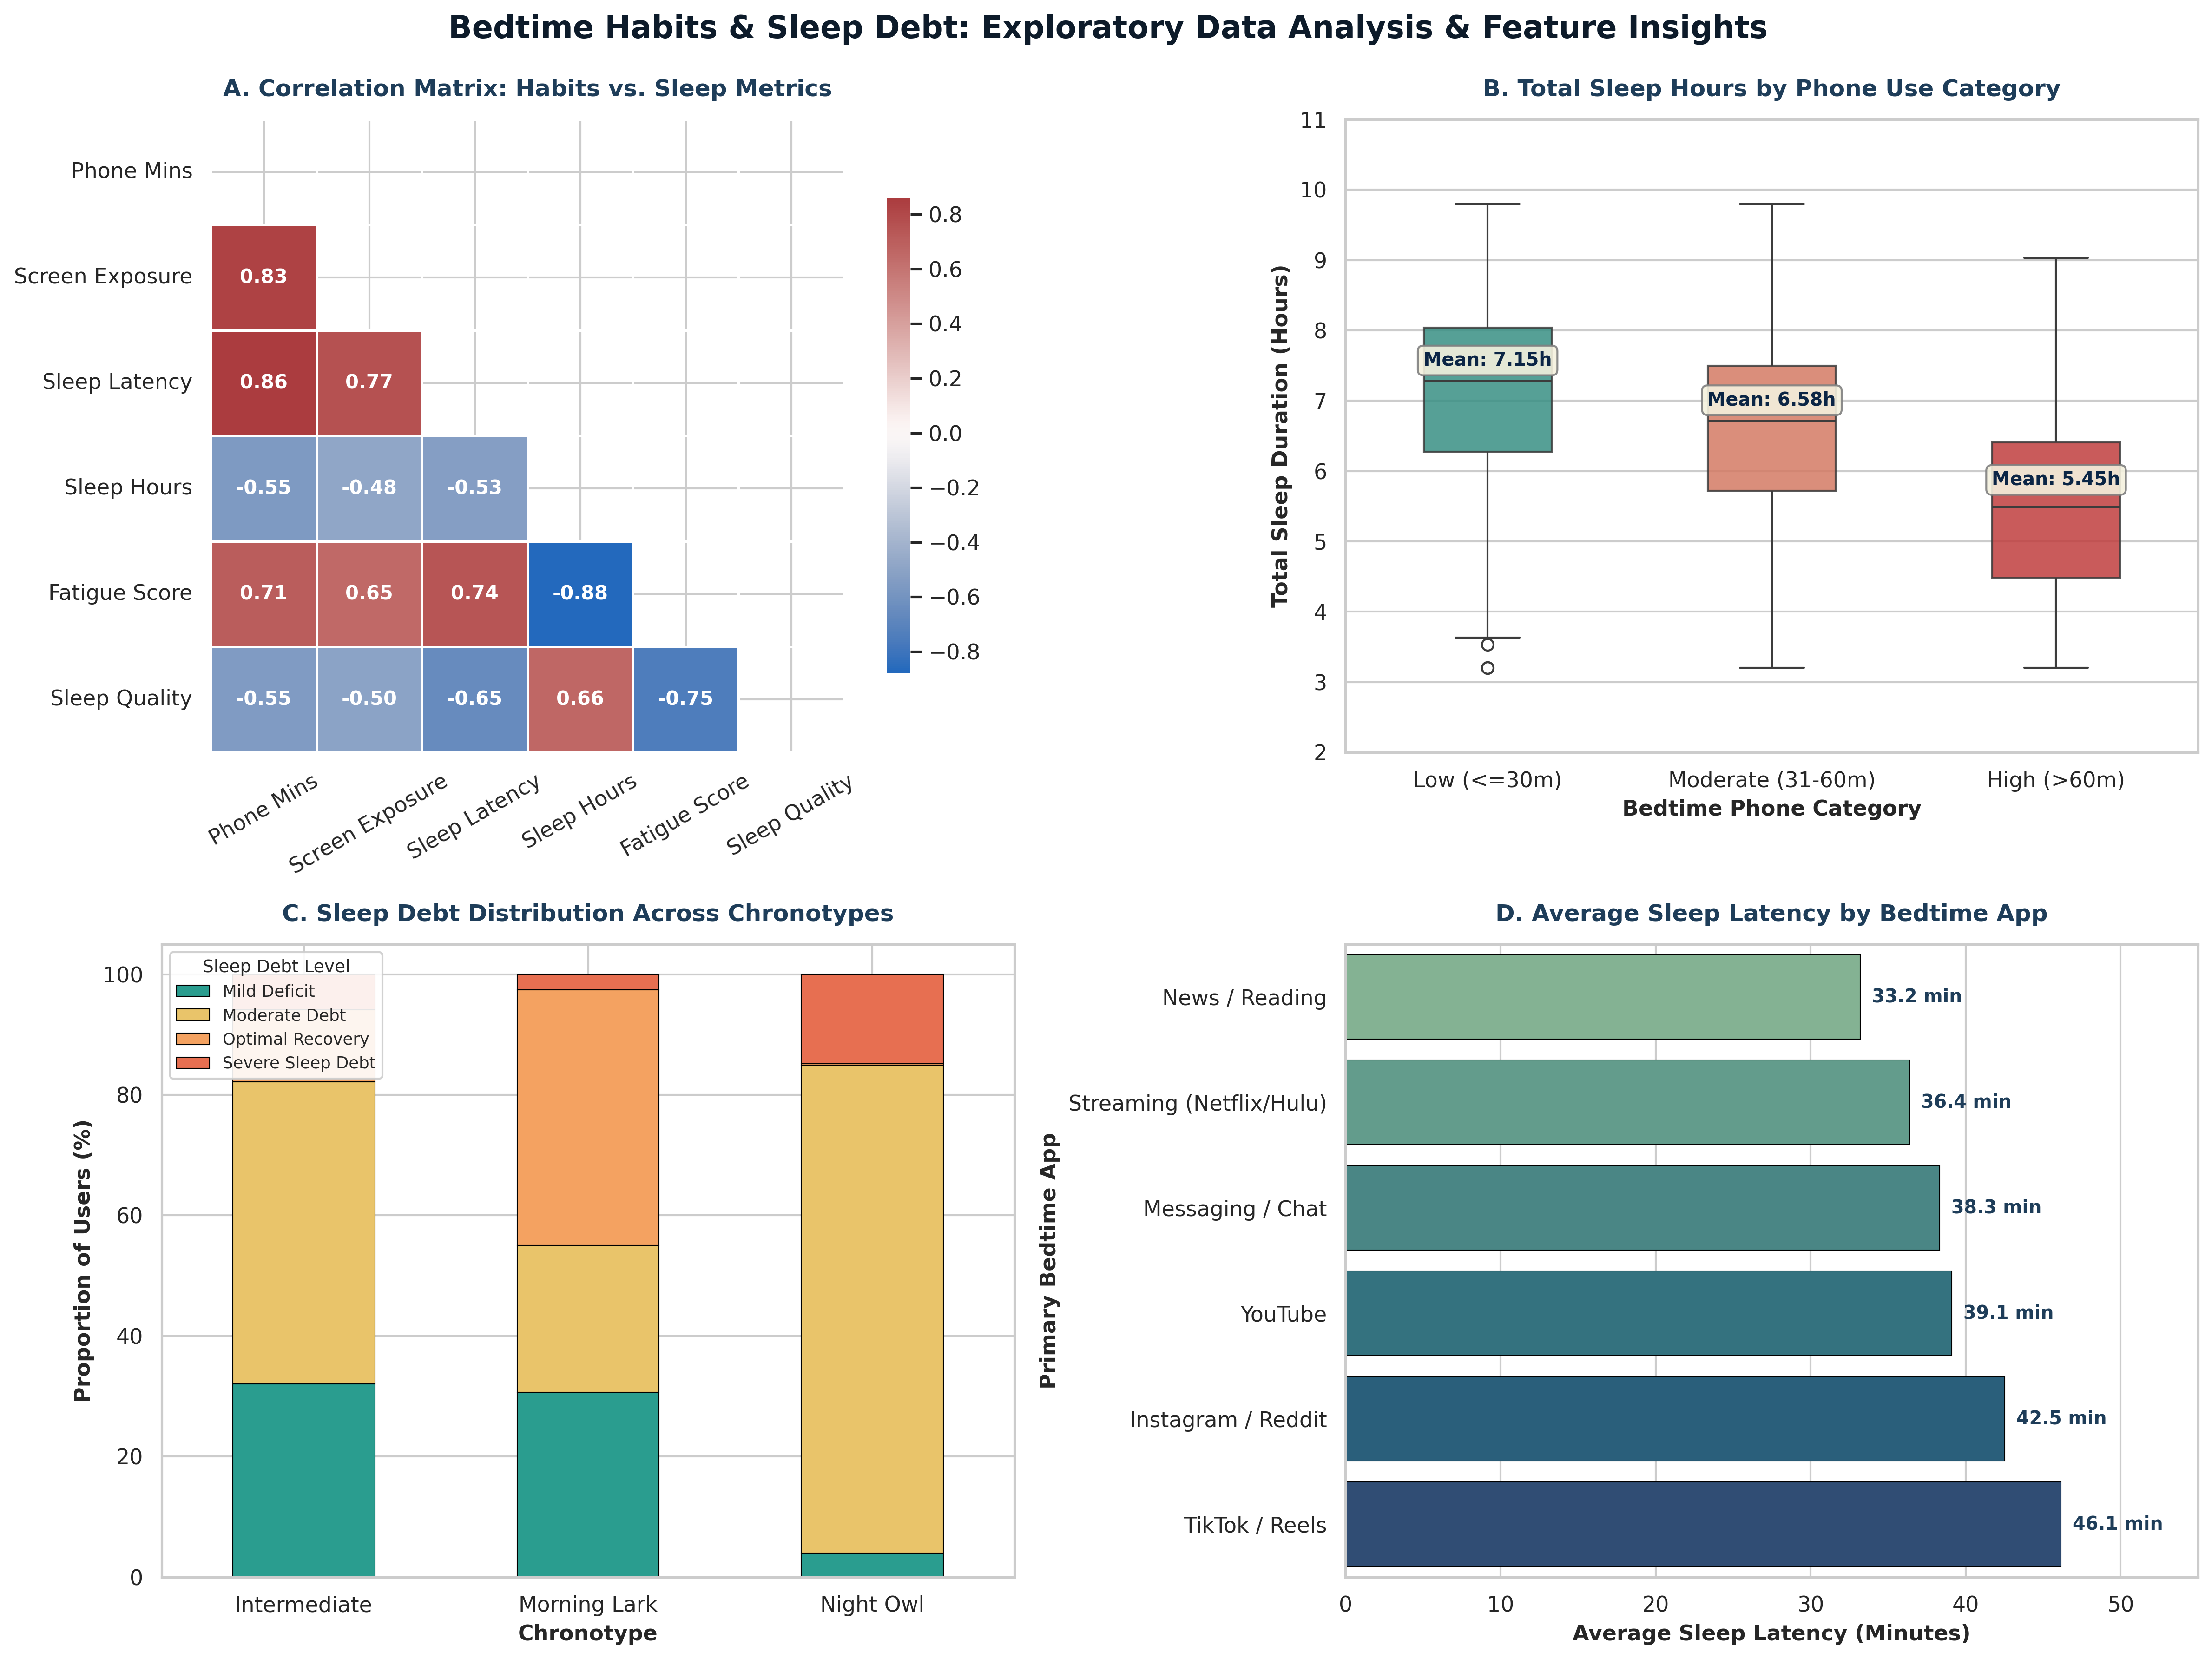

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# تحميل ومعالجة البيانات الأساسية
df = pd.read_csv('bedtime_screentime_sleep_debt.csv')

# تطبيق Feature Engineering
df['phone_use_category'] = pd.cut(
    df['bedtime_phone_minutes'],
    bins=[0, 30, 60, np.inf],
    labels=['Low (<=30m)', 'Moderate (31-60m)', 'High (>60m)'],
    include_lowest=True,
)

df['bedtime_screen_exposure'] = (
    df['bedtime_phone_minutes'] * df['screen_brightness_pct'] / 100
)

df['sleep_quality_score'] = (
    df['total_sleep_hours'].between(7, 9).astype(int)
    + (df['sleep_latency_min'] <= 30).astype(int)
    + (df['deep_sleep_pct'] >= 20).astype(int)
    + (df['rem_sleep_pct'] >= 20).astype(int)
    + (df['next_day_fatigue_score'] <= 3).astype(int)
)

# ضبط المظهر العام
sns.set_theme(style='whitegrid', font='sans-serif')
primary_color = '#1E3D59'
category_order = ['Low (<=30m)', 'Moderate (31-60m)', 'High (>60m)']
palette_cat = ['#2A9D8F', '#E76F51', '#D62828']

# 1. لوحة الـ Dashboard المجمعة
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=300)
plt.subplots_adjust(hspace=0.35, wspace=0.3)

# Subplot 1: Correlation Matrix
corr_cols = [
    'bedtime_phone_minutes',
    'bedtime_screen_exposure',
    'sleep_latency_min',
    'total_sleep_hours',
    'next_day_fatigue_score',
    'sleep_quality_score',
]
corr_labels = [
    'Phone Mins',
    'Screen Exposure',
    'Sleep Latency',
    'Sleep Hours',
    'Fatigue Score',
    'Sleep Quality',
]
corr_mat = df[corr_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(
    corr_mat,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    center=0,
    square=True,
    linewidths=1.2,
    cbar_kws={'shrink': 0.75},
    ax=axes[0, 0],
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    annot_kws={'size': 10, 'weight': 'bold'},
)
axes[0, 0].set_title(
    'A. Correlation Matrix: Habits vs. Sleep Metrics',
    fontsize=12,
    pad=12,
    weight='bold',
    color=primary_color,
)
axes[0, 0].tick_params(axis='x', rotation=30)

# Subplot 2: Sleep Duration Boxplot
sns.boxplot(
    data=df,
    x='phone_use_category',
    y='total_sleep_hours',
    order=category_order,
    palette=palette_cat,
    ax=axes[0, 1],
    width=0.45,
    boxprops=dict(alpha=0.85),
)
axes[0, 1].set_title(
    'B. Total Sleep Hours by Phone Use Category',
    fontsize=12,
    pad=12,
    weight='bold',
    color=primary_color,
)
axes[0, 1].set_xlabel('Bedtime Phone Category', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('Total Sleep Duration (Hours)', fontsize=11, weight='bold')
axes[0, 1].set_ylim(2, 11)

means = df.groupby('phone_use_category')['total_sleep_hours'].mean()
for i, cat in enumerate(category_order):
  axes[0, 1].text(
      i,
      means[cat] + 0.35,
      f'Mean: {means[cat]:.2f}h',
      ha='center',
      weight='bold',
      color='#0B2545',
      fontsize=9.5,
      bbox=dict(
          boxstyle='round,pad=0.3',
          facecolor='#F4F1DE',
          alpha=0.9,
          edgecolor='gray',
      ),
  )

# Subplot 3: Chronotype Stacked Bar
debt_cross = (
    pd.crosstab(df['chronotype'], df['sleep_debt_category'], normalize='index')
    * 100
)
colors_debt = ['#2A9D8F', '#E9C46A', '#F4A261', '#E76F51']
debt_cross.plot(
    kind='bar',
    stacked=True,
    ax=axes[1, 0],
    color=colors_debt,
    edgecolor='black',
    linewidth=0.5,
)
axes[1, 0].set_title(
    'C. Sleep Debt Distribution Across Chronotypes',
    fontsize=12,
    pad=12,
    weight='bold',
    color=primary_color,
)
axes[1, 0].set_xlabel('Chronotype', fontsize=11, weight='bold')
axes[1, 0].set_ylabel('Proportion of Users (%)', fontsize=11, weight='bold')
axes[1, 0].legend(
    title='Sleep Debt Level',
    fontsize=8.5,
    title_fontsize=9,
    loc='upper left',
    framealpha=0.9,
)
axes[1, 0].tick_params(axis='x', rotation=0)

# Subplot 4: Sleep Latency by Bedtime App
app_metrics = (
    df.groupby('primary_bedtime_app')
    .agg(avg_latency=('sleep_latency_min', 'mean'))
    .reset_index()
    .sort_values('avg_latency', ascending=True)
)
sns.barplot(
    data=app_metrics,
    x='avg_latency',
    y='primary_bedtime_app',
    palette='crest',
    ax=axes[1, 1],
    edgecolor='black',
    linewidth=0.5,
)
axes[1, 1].set_title(
    'D. Average Sleep Latency by Bedtime App',
    fontsize=12,
    pad=12,
    weight='bold',
    color=primary_color,
)
axes[1, 1].set_xlabel(
    'Average Sleep Latency (Minutes)', fontsize=11, weight='bold'
)
axes[1, 1].set_ylabel('Primary Bedtime App', fontsize=11, weight='bold')
axes[1, 1].set_xlim(0, 55)

for p in axes[1, 1].patches:
  width = p.get_width()
  axes[1, 1].annotate(
      f'{width:.1f} min',
      xy=(width, p.get_y() + p.get_height() / 2),
      xytext=(6, 0),
      textcoords='offset points',
      ha='left',
      va='center',
      fontsize=9.5,
      weight='bold',
      color='#1E3D59',
  )

fig.suptitle(
    'Bedtime Habits & Sleep Debt: Exploratory Data Analysis & Feature Insights',
    fontsize=16,
    weight='bold',
    y=0.99,
    color='#0D1B2A',
)
plt.tight_layout()
plt.savefig('bedtime_sleep_eda_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()